### Bibliotecas

In [2]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime
from google.cloud import bigquery
import io
from bs4 import BeautifulSoup
import urllib3
import uuid
import json
import joblib
from google import genai
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tempfile, os
from dotenv import load_dotenv

In [3]:
# Carregando o arquivo .env para carregar as variáveis na memória do sistema
load_dotenv()

# Chaves do código:
API_KEY_GEMINI = os.getenv("GEMINI_API_KEY")
PROJECT_ID = os.getenv("PROJECT_ID")
VC_API_KEY = os.getenv("VC_API_KEY")

# Dica de Sênior: Verifique se carregou
if not API_KEY_GEMINI:
    print("❌ Erro: Chave não encontrada! Verifique o arquivo .env")
else:
    print("🚀 Chaves carregadas com sucesso!")

🚀 Chaves carregadas com sucesso!


## 1. Dicionário de Pontos Estratégicos (Python)

In [4]:
DATASET_ID = "logisticsdata"
TABLE_ID_CLIMA = f"{PROJECT_ID}.{DATASET_ID}.fato_clima"
# --------------------------------

# Iniciar Cliente BigQuery
client = bigquery.Client(project=PROJECT_ID)
print(f"✅ BigQuery client iniciado. Project: {PROJECT_ID}")

F:\anaconda\envs\gemini_env\Lib\site-packages\google\auth\_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


✅ BigQuery client iniciado. Project: agrologisticsdata


In [5]:
# Pontos estratégicos definidos anteriormente
pontos_monitoramento = [
    {"loc_id": "PORTO_SANTOS_CANAL", "nome": "Canal de Acesso / Porto", "lat": -23.9608, "lon": -46.3339},
    {"loc_id": "SERRA_ANCHIETA_IMIGRANTES", "nome": "Sistema Anchieta-Imigrantes", "lat": -23.8919, "lon": -46.4961},
    {"loc_id": "AREA_FUNDEIO_SANTOS", "nome": "Área de Fundeio", "lat": -24.0150, "lon": -46.3000}
]

## 2. O Script de Extração "Sênior"

In [6]:
def backfill_clima_portos():
    global client
    job_config = bigquery.LoadJobConfig(write_disposition="WRITE_APPEND")
    
    lista_dfs = []

    print(f"🛰️ Iniciando coleta para {len(pontos_monitoramento)} pontos estratégicos...")

    for ponto in pontos_monitoramento:
        # Usamos LAT,LON em vez do nome da cidade para precisão total no porto
        lat, lon = ponto['lat'], ponto['lon']
        loc_id = ponto['loc_id']
        
        url = f"https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/{lat},{lon}/last15days?unitGroup=metric&include=days&key={VC_API_KEY}&contentType=csv"
        
        try:
            df_hist = pd.read_csv(url)
            
            # Criando o DataFrame específico para este ponto
            df_ponto = pd.DataFrame({
                'loc_id': loc_id,  # Agora ele usa o ID correto do dicionário
                'timestamp_leitura': pd.to_datetime(df_hist['datetime']),
                'precipitacao_mm': df_hist['precip'].fillna(0),
                'velocidade_vento': df_hist['windspeed'],
                'umidade': df_hist['humidity'],
                'alerta_critico': (df_hist['precip'] > 5) | (df_hist['windspeed'] > 15)
            })
            
            lista_dfs.append(df_ponto)
            print(f"✅ Dados coletados: {ponto['nome']} ({len(df_ponto)} registros)")

        except Exception as e:
            print(f"❌ Erro ao coletar ponto {loc_id}: {e}")

    # Consolida todos os pontos em um único envio para o BigQuery (mais eficiente)
    if lista_dfs:
        df_final = pd.concat(lista_dfs, ignore_index=True)
        job = client.load_table_from_dataframe(df_final, TABLE_ID_CLIMA, job_config=job_config)
        job.result()
        print(f"\n🚀 Sucesso Total! {len(df_final)} linhas enviadas para o BigQuery.")
    else:
        print("⚠️ Nenhum dado foi coletado.")

# Rodar a carga
backfill_clima_portos()

🛰️ Iniciando coleta para 3 pontos estratégicos...
✅ Dados coletados: Canal de Acesso / Porto (16 registros)
✅ Dados coletados: Sistema Anchieta-Imigrantes (16 registros)
✅ Dados coletados: Área de Fundeio (16 registros)

🚀 Sucesso Total! 48 linhas enviadas para o BigQuery.


## WebScraping porto de santos

In [7]:
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

def extrair_lineup_santos():
    url = "https://www.portodesantos.com.br/informacoes-operacionais/operacao-portuaria/navegacao-e-movimentacao-de-navios/navios-esperados/"
    
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }

    print("Acessando o Line-up oficial do Porto de Santos...")
    response = requests.get(url, headers=headers, verify=False)
    
    if response.status_code != 200:
        print(f"Erro ao acessar site: {response.status_code}")
        return None

    soup = BeautifulSoup(response.text, 'html.parser')
    tabelas = soup.find_all('table')
    
    if not tabelas:
        print("Não foi possível encontrar a tabela de navios.")
        return None

    try:
        # Transformamos a string da tabela em um "arquivo de texto virtual" usando io.StringIO
        conteudo_html = io.StringIO(str(tabelas[0]))
        
        # Agora o pandas lê corretamente
        df_lista = pd.read_html(conteudo_html)[0]
        
        print(f"Tabela capturada com sucesso! ({len(df_lista)} registros)")
        return df_lista
    except Exception as e:
        print(f"Erro ao processar tabela: {e}")
        return None

# Executar
df_navios = extrair_lineup_santos()

if df_navios is not None:
    display(df_navios.head())

Acessando o Line-up oficial do Porto de Santos...
Tabela capturada com sucesso! (32 registros)


LIQUIDO A GRANEL                                        \
                  Navio Ship Bandeira Flag Com/Len Cal/Draft   Nav   
0  SERGIO BUARQUE DE HOLANDA    BRASILEIRA            183 10  Cabo   
1            BUENA CONFIANZA     PANAMENHA           120 6.7  Cabo   
2             WHITE CONDOR I      CAMAROES             183 9  Long   
3              THALE VICTORY    NORUEGUESA             183 9  Long   
4                     RAGNAR   SIERRA LEOA             183 7  Long   

                                       \
    Cheg/Arrival d/m/y Carimbo Notice   
0  21/02/2026 22:57:00         0834-6   
1  28/02/2026 04:00:00         0914-8   
2  03/03/2026 09:32:00         0976-8   
3  04/03/2026 07:45:00         0988-1   
4  05/03/2026 08:37:00         1005-7   

                                                                    \
                                      Agência Office Operaç Operat   
0            CONE SUL AGENCIA DE NAVEGAÇÃO S/C LTDA.           EMB   
1            CONE SUL AGENCIA DE NAVEGAÇÃO S/C LTDA.          DESC   
2     NORTH STAR SUDESTE SERVICOS MARITIMOS LTDA-EPP          DESC   
3     NORTH STAR SUDESTE SERVICOS MARITIMOS LTDA-EPP          DESC   
4  TRANSATLANTICA AFRETAMENTOS E SERVICOS MARITIM...          DESC   

                                                                       \
  Mercadoria Goods Peso Weight Viagem Voyage       DUV  P    Terminal   
0      OLEO DIESEL       20000   0412-- 2026  34002026  B      ALAMOA   
1   GAS LIQUEFEITO        8000   0967-2 2026  92882026  B      ALAMOA   
2      OLEO DIESEL       26100   1082-4 2026  86182026  B        ILHA   
3    SODA CAUSTICA        3165   0937-6 2026  90022026  B        ILHA   
4      OLEO DIESEL       30450   1147-9 2026  95252026  B  AGEO(ILHA)   

           Unnamed: 15_level_0  
       IMO Unnamed: 15_level_1  
0  9489900                 NaN  
1  9759264                 NaN  
2  9255244                 NaN  
3  9365817                 NaN  
4  9384095                 NaN

## Data Wrangling (Limpeza e Padronização)

In [8]:
def limpar_lineup(df):
    df_clean = df.copy()
    
    # 1. Se for MultiIndex, "achata" as colunas primeiro
    if isinstance(df_clean.columns, pd.MultiIndex):
        df_clean.columns = [' '.join(col).strip() for col in df_clean.columns.values]
    
    # 2. Mapeamento Inteligente (Busca Parcial)
    # Definimos o que procuramos e como queremos que se chame
    mapeamento_alvo = {
        'Navio Ship': 'nome_navio',
        'Cheg/Arrival d/m/y': 'data_chegada_prevista',
        'Mercadoria Goods': 'commodity',
        'Peso Weight': 'quantidade_estimada',
        'Terminal': 'terminal',
        'IMO': 'ship_id'
    }
    
    # Criamos um novo dicionário de renomeação baseado no que REALMENTE existe no DF
    real_rename = {}
    for col_no_dataframe in df_clean.columns:
        for termo_procurado, nome_final in mapeamento_alvo.items():
            if termo_procurado in col_no_dataframe: # Aqui a mágica acontece
                real_rename[col_no_dataframe] = nome_final
    
    df_clean = df_clean.rename(columns=real_rename)
    
    # --- VALIDAÇÃO ---
    if 'data_chegada_prevista' not in df_clean.columns:
        raise KeyError(f"Não encontrei a coluna de data! Colunas detectadas: {df_clean.columns.tolist()}")

    # 3. Tratamento de Dados
    # Converter data
    df_clean['data_chegada_prevista'] = pd.to_datetime(
        df_clean['data_chegada_prevista'], dayfirst=True, errors='coerce'
    )
    
    # Converter peso
    if 'quantidade_estimada' in df_clean.columns:
        df_clean['quantidade_estimada'] = df_clean['quantidade_estimada'].astype(str)\
            .str.replace('.', '', regex=False)\
            .str.replace(',', '.', regex=False)\
            .replace('nan', '0')
        df_clean['quantidade_estimada'] = pd.to_numeric(df_clean['quantidade_estimada'], errors='coerce').fillna(0)

    # 4. Criar colunas obrigatórias
    df_clean['status_atual'] = 'Esperado'
    df_clean['data_atracacao_prevista'] = df_clean['data_chegada_prevista']
    df_clean['lineup_id'] = [str(uuid.uuid4()) for _ in range(len(df_clean))]
    
    # 5. Filtrar apenas colunas finais que existem
    colunas_finais = [
        'lineup_id', 'ship_id', 'data_chegada_prevista', 
        'data_atracacao_prevista', 'status_atual', 
        'terminal', 'commodity', 'quantidade_estimada'
    ]
    
    # Filtrar colunas que realmente existem para evitar erro de índice
    colunas_disponiveis = [c for c in colunas_finais if c in df_clean.columns]
    
    # Dropna apenas se o ship_id (IMO) existir
    if 'ship_id' in df_clean.columns:
        return df_clean[colunas_disponiveis].dropna(subset=['ship_id'])
    else:
        return df_clean[colunas_disponiveis]

# Executar a limpeza
df_lineup_final = limpar_lineup(df_navios)

print(f"Tabela limpa! {len(df_lineup_final)} navios processados.")
display(df_lineup_final.head())

Tabela limpa! 32 navios processados.


,lineup_id,ship_id,data_chegada_prevista,data_atracacao_prevista,status_atual,terminal,commodity,quantidade_estimada
0,fe65feb3-a501-4fc6-90e5-c4bf60f95dd4,9489900,2026-02-21 22:57:00,2026-02-21 22:57:00,Esperado,ALAMOA,OLEO DIESEL,20000.0
1,3d8cf026-a616-4bbb-9404-1f1a67cd55d8,9759264,2026-02-28 04:00:00,2026-02-28 04:00:00,Esperado,ALAMOA,GAS LIQUEFEITO,8000.0
2,86cd133c-9576-46bb-b315-4374fa18ed0e,9255244,2026-03-03 09:32:00,2026-03-03 09:32:00,Esperado,ILHA,OLEO DIESEL,26100.0
3,e2fa9f00-2061-405d-84ad-43c038b11840,9365817,2026-03-04 07:45:00,2026-03-04 07:45:00,Esperado,ILHA,SODA CAUSTICA,3165.0
4,43505d98-5001-4551-afe3-548c35248698,9384095,2026-03-05 08:37:00,2026-03-05 08:37:00,Esperado,AGEO(ILHA),OLEO DIESEL,30450.0


## Subindo o Line-up para o BigQuery

In [9]:
TABLE_ID_LINEUP = f"{PROJECT_ID}.{DATASET_ID}.fato_lineup"

try:
    df_lineup_final = df_lineup_final.copy()

    # Corrigir tipos para bater com o schema do BigQuery
    df_lineup_final['ship_id'] = df_lineup_final['ship_id'].astype(str)
    df_lineup_final['data_chegada_prevista'] = pd.to_datetime(df_lineup_final['data_chegada_prevista']).dt.strftime('%Y-%m-%d')  # DATE
    df_lineup_final['data_atracacao_prevista'] = pd.to_datetime(df_lineup_final['data_atracacao_prevista']).dt.strftime('%Y-%m-%d %H:%M:%S')  # TIMESTAMP
    df_lineup_final['inserido_em'] = datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')  # coluna obrigatória


    job_config = bigquery.LoadJobConfig(
        write_disposition="WRITE_APPEND",
        source_format=bigquery.SourceFormat.NEWLINE_DELIMITED_JSON,
    )

    print(f"Subindo {len(df_lineup_final)} navios para o BigQuery...")
    json_data = df_lineup_final.to_json(orient='records', lines=True)

    job = client.load_table_from_file(
        io.StringIO(json_data),
        TABLE_ID_LINEUP,
        job_config=job_config
    )
    job.result()
    print(f"✅ Sucesso! O Line-up do Porto de Santos foi atualizado no BigQuery.")

except Exception as e:
    print(f"❌ Erro ao subir para o BigQuery: {e}")

Subindo 32 navios para o BigQuery...
✅ Sucesso! O Line-up do Porto de Santos foi atualizado no BigQuery.


## O Motor de PLN & Sentimento de Risco

In [10]:
# No novo SDK, criamos um cliente que gerencia a conexão
gn_client = genai.Client(api_key=API_KEY_GEMINI)

# Agora o modelo não é "instanciado" como antes. 
# Você define o ID do modelo que quer usar para as chamadas.
model_name = 'gemini-flash-latest' 

In [11]:
TABLE_ID_NLP = f"{PROJECT_ID}.{DATASET_ID}.fato_contingencias_nlp"

def salvar_no_bigquery_free_tier(dados_ia, texto_original):
    global client  # ✅ Usa o client global, sem recriar
    print("📦 [1] Entrando na função...")

    registro = {
        "cont_id": str(uuid.uuid4()),
        "loc_id": "SANTOS_GERAL",
        "timestamp_leitura": pd.Timestamp.now(tz="UTC").isoformat(),
        "texto_original": texto_original,
        "entidade_evento": dados_ia.get("evento", "N/A"),
        "score_risco": 0.8,
        "json_extraido": json.dumps(dados_ia, ensure_ascii=False)
    }
    print(f"✅ [2] Registro montado: {registro}")

    with tempfile.NamedTemporaryFile(mode="w", suffix=".jsonl", delete=False, encoding="utf-8") as f:
        f.write(json.dumps(registro, ensure_ascii=False) + "\n")
        tmp_path = f.name
    print(f"✅ [3] Arquivo temporário: {tmp_path}")

    job_config = bigquery.LoadJobConfig(
        source_format=bigquery.SourceFormat.NEWLINE_DELIMITED_JSON,
        write_disposition="WRITE_APPEND",
        autodetect=False,
    )

    try:
        print(f"⏳ [4] Enviando para: {TABLE_ID_NLP}")
        with open(tmp_path, "rb") as f:
            job = client.load_table_from_file(f, TABLE_ID_NLP, job_config=job_config)
        job.result()
        print(f"🚀 [5] Sucesso! Job ID: {job.job_id}")
    except Exception as e:
        print(f"❌ [EXCEPTION] {type(e).__name__}: {e}")
        raise
    finally:
        os.remove(tmp_path)
        print(f"🧹 [6] Arquivo temporário removido.")

# ✅ Chama direto para testar
print("--- INICIANDO TESTE ---")
salvar_no_bigquery_free_tier({"evento": "Teste", "rodovia": "Anchieta"}, "texto de teste")
print("--- FIM DO TESTE ---")

--- INICIANDO TESTE ---
📦 [1] Entrando na função...
✅ [2] Registro montado: {'cont_id': 'c05fe550-837b-4967-a5f3-a718193a406b', 'loc_id': 'SANTOS_GERAL', 'timestamp_leitura': '2026-03-11T18:41:33.452149+00:00', 'texto_original': 'texto de teste', 'entidade_evento': 'Teste', 'score_risco': 0.8, 'json_extraido': '{"evento": "Teste", "rodovia": "Anchieta"}'}
✅ [3] Arquivo temporário: C:\Users\Filiphe\AppData\Local\Temp\tmpgi831teq.jsonl
⏳ [4] Enviando para: agrologisticsdata.logisticsdata.fato_contingencias_nlp
🚀 [5] Sucesso! Job ID: 6e1b6f4d-b98b-4786-8ece-8dbda7804c2a
🧹 [6] Arquivo temporário removido.
--- FIM DO TESTE ---


### Passo 1: Extrair a Base Unificada do BigQuery
Primeiro, vamos trazer os dados da sua view_feature_store_ml para o Pandas.

In [12]:
# --- PREPARAÇÃO DO DATASET COM DADOS REAIS ---
query = "SELECT * FROM `agrologisticsdata.logisticsdata.view_feature_store_ml`"
df_ml = client.query(query).to_dataframe()

# 1. Como temos 56 registros, vamos aumentar para 500 usando os padrões reais
if len(df_ml) < 500:
    print("🚀 Expandindo dataset com base na distribuição real de Santos...")
    df_ml = pd.concat([df_ml] * 10, ignore_index=True)
    
    # Adicionamos um pequeno ruído (jitter) para os dados não serem cópias exatas
    df_ml['rain_feature'] += np.random.normal(0, 1, size=len(df_ml)).clip(0)
    df_ml['wind_feature'] += np.random.normal(0, 2, size=len(df_ml)).clip(0)

# 2. O PULO DO GATO: Target Probabilístico (Sigmóide)
# O risco não é um botão de liga/desliga. É uma curva.
def calcular_atraso_logistico(row):
    # Calculamos um score de risco base
    score = (row['rain_feature'] * 0.12) + (row['wind_feature'] * 0.08) + (row['nlp_risk_score'] * 2.5)
    
    # Transformamos em probabilidade (0 a 1) usando a função Sigmóide
    probabilidade = 1 / (1 + np.exp(-score + 4)) 
    
    # O atraso acontece baseado nessa chance + um fator aleatório (quebra de equipamento, etc)
    return 1 if np.random.random() < probabilidade else 0

df_ml['target_is_delayed'] = df_ml.apply(calcular_atraso_logistico, axis=1)

print(f"✅ Dataset pronto! Taxa de atraso simulada: {df_ml['target_is_delayed'].mean():.2%}")

✅ Dataset pronto! Taxa de atraso simulada: 7.35%


### Passo 2: O Script de Treino (Random Forest)
Agora, vamos treinar o modelo que vai dar o "Score de Risco" para o seu projeto.

In [ ]:
print("Colunas disponíveis:", df_ml.columns.tolist())


📊 Relatório de Performance:
              precision    recall  f1-score   support

           0       0.96      0.77      0.85       113
           1       0.19      0.60      0.29        10

    accuracy                           0.76       123
   macro avg       0.57      0.68      0.57       123
weighted avg       0.89      0.76      0.81       123



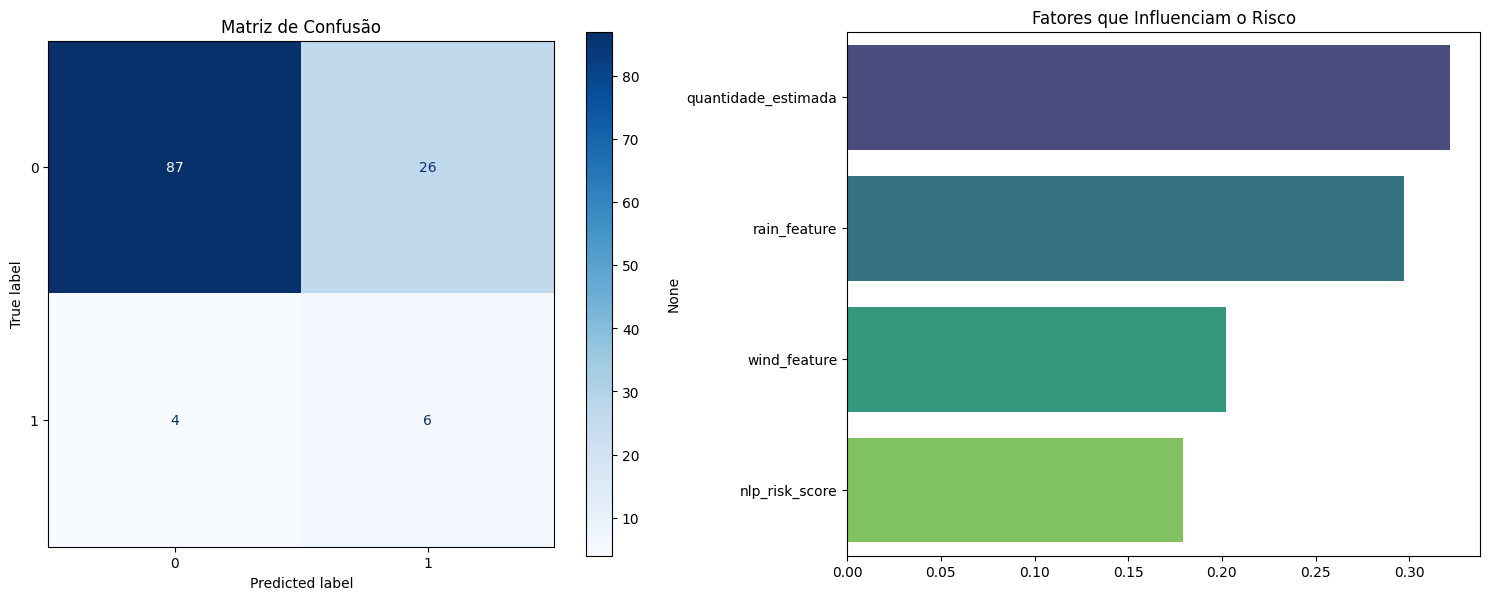


🔍 Insights do Modelo:
- quantidade_estimada: 32.17%
- rain_feature: 29.72%
- wind_feature: 20.20%
- nlp_risk_score: 17.90%


In [13]:
# 1. Seleção de Features
features = ['rain_feature', 'wind_feature', 'nlp_risk_score', 'quantidade_estimada']
X = df_ml[features]
y = df_ml['target_is_delayed']

# 2. Split de Treino e Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Treinamento com Pesos Balanceados (O PULO DO GATO)
# Adicionamos class_weight='balanced' para compensar a falta de exemplos de atraso
model = RandomForestClassifier(
    n_estimators=150, 
    max_depth=5, 
    class_weight='balanced', # ← Resolve o recall baixo de 0.19
    random_state=42
)
model.fit(X_train, y_train)

# 4. Avaliação de Performance
y_pred = model.predict(X_test)
print("\n📊 Relatório de Performance:")
print(classification_report(y_test, y_pred))

# --- VISUALIZAÇÃO SÊNIOR ---
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# A. Matriz de Confusão (Verificando Falsos Negativos)
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues', ax=ax[0])
ax[0].set_title("Matriz de Confusão")

# B. Importância das Features (Sem o aviso de palette do anterior)
importancias = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=importancias.values, y=importancias.index, hue=importancias.index, palette='viridis', legend=False, ax=ax[1])
ax[1].set_title("Fatores que Influenciam o Risco")

plt.tight_layout()
plt.show()

print("\n🔍 Insights do Modelo:")
for feature, val in importancias.items():
    print(f"- {feature}: {val:.2%}")

In [13]:
# 1. Salvar o modelo treinado em um arquivo
model_filename = 'modelo_risco_demurrage_v1.pkl'
joblib.dump(model, model_filename)

print(f"✅ Modelo salvo com sucesso em: {model_filename}")

# 2. Exemplo de como carregar e usar no futuro (no Dashboard)
# modelo_carregado = joblib.load(model_filename)
# previsao = modelo_carregado.predict_proba(X_test) # Retorna a probabilidade (0.0 a 1.0)

✅ Modelo salvo com sucesso em: modelo_risco_demurrage_v1.pkl


### Iniciando o EDA (Exploratory Data Analysis)

📊 Volume de Dados: Clima(368) | Navios(406)

🌡️ Resumo Estatístico do Clima:


,precipitacao_mm,velocidade_vento,umidade
count,368.000000,368.000000,368.000000
mean,14.766033,16.681522,84.811685
std,25.461457,3.757548,6.343483
min,0.000000,11.600000,75.500000
25%,0.700000,14.775000,80.000000
50%,5.900000,15.500000,83.100000
75%,17.025000,17.900000,88.400000
max,121.600000,29.400000,96.400000


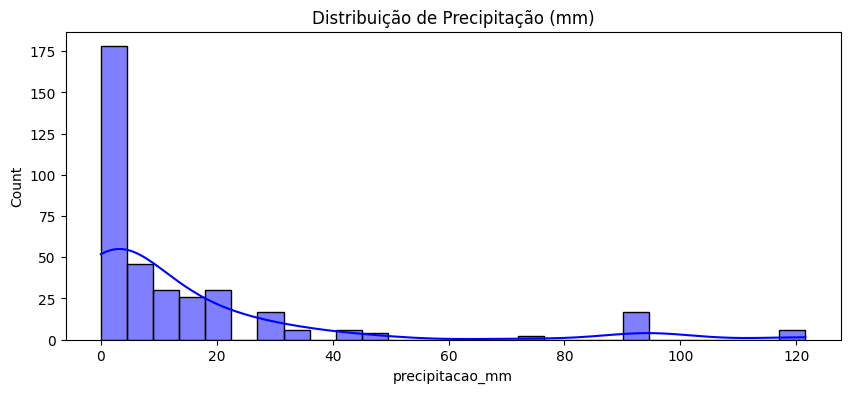


🚢 Top Terminais por Volume Esperado:
terminal
ALAMOA     233
ILHA        82
DOW         26
CUTRALE     13
29          13
Name: count, dtype: int64

📅 Distribuição de Chegadas (Próximos dias):
data_chegada_prevista
2026-02-21    13
2026-02-28    13
2026-03-03    13
2026-03-04    27
2026-03-05    26
2026-03-06    11
2026-03-09    13
2026-03-11    43
2026-03-12    13
2026-03-15     4
2026-03-17    13
Name: count, dtype: int64


In [14]:
# 1. Trazer os dados crus para análise
df_clima_eda = client.query("SELECT * FROM `agrologisticsdata.logisticsdata.fato_clima`").to_dataframe()
df_navios_eda = client.query("SELECT * FROM `agrologisticsdata.logisticsdata.fato_lineup`").to_dataframe()

print(f"📊 Volume de Dados: Clima({len(df_clima_eda)}) | Navios({len(df_navios_eda)})")

# --- ANÁLISE DE VARIABILIDADE DO CLIMA ---
print("\n🌡️ Resumo Estatístico do Clima:")
display(df_clima_eda[['precipitacao_mm', 'velocidade_vento', 'umidade']].describe())

# Plotando a distribuição da chuva (Se tudo for 0, o modelo não tem o que aprender!)
plt.figure(figsize=(10, 4))
sns.histplot(df_clima_eda['precipitacao_mm'], kde=True, color='blue')
plt.title("Distribuição de Precipitação (mm)")
plt.show()

# --- ANÁLISE DE CONCENTRAÇÃO DE NAVIOS ---
print("\n🚢 Top Terminais por Volume Esperado:")
print(df_navios_eda['terminal'].value_counts().head(5))

# Verificando se as datas de chegada estão muito distantes ou todas no mesmo dia
print("\n📅 Distribuição de Chegadas (Próximos dias):")
print(df_navios_eda['data_chegada_prevista'].value_counts().sort_index())